# Proyek Analisis Data: Bike-sharing-dataset
- **Nama:** Syahrani.R
- **Email:** cdcc304d6x1444@student.devacademy.id
- **ID Dicoding:** syahranir8

In [68]:
readme = "Readme.txt"
with open(readme, "r") as file:
  isi_file = file.read()
  print(isi_file)

Bike Sharing Dataset

Hadi Fanaee-T

Laboratory of Artificial Intelligence and Decision Support (LIAAD), University of Porto
INESC Porto, Campus da FEUP
Rua Dr. Roberto Frias, 378
4200 - 465 Porto, Portugal


Background 

Bike sharing systems are new generation of traditional bike rentals where whole process from membership, rental and return 
back has become automatic. Through these systems, user is able to easily rent a bike from a particular position and return 
back at another position. Currently, there are about over 500 bike-sharing programs around the world which is composed of 
over 500 thousands bicycles. Today, there exists great interest in these systems due to their important role in traffic, 
environmental and health issues. 

Apart from interesting real world applications of bike sharing systems, the characteristics of data being generated by
these systems make them attractive for the research. Opposed to other transport services such as bus or subway, the duration
of tra

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Bagaimana tren jumlah penyewaan sepeda per jam pada hari kerja (workingday) dibandingkan hari libur (weekend) sepanjang periode 2011 hingga 2012?
- Pertanyaan 2 : Bagaimana pengaruh variasi kondisi cuaca (cuaca cerah hingga ekstrem) terhadap performa jumlah penyewaan sepeda harian selama tahun 2011-2012?

## Import Semua Packages/Library yang Digunakan

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [70]:
day_df = pd.read_csv('day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [71]:
hour_df = pd.read_csv('hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset ini diperoleh dari program Coding Camp (bersumber dari Kaggle) dalam format CSV yang terdiri dari dua tabel utama, yaitu day_df (day.csv : 16 kolom) untuk data harian dan hour_df (hour.csv : 17 kolom) untuk data per jam. Perbedaan utama terletak pada kolom hr yang hanya tersedia di tabel per jam  untuk menunjukkan waktu pencatatan (0-23)
- Melihat dari karakteristik variabel. Data mencakup informasi kronologis (tanggal, musim, bulan, tahun), kondisi lingkungan (cuaca, suhu, kelembapan, kecepatan angin yang telah dinormalisasi), serta status hari (hari libur atau hari kerja). Variabel target utama adalah cnt, yang merupakan total penyewaan sepeda hasil penggabungan antara pengguna pengguna tipe casual (tidak terdaftar) dan registered (terdaftar).

### Assessing Data

In [72]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [73]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [74]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


In [75]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [76]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [77]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [78]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())
hour_df.describe()

Jumlah duplikasi:  0


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Berdasarkan pengecekan menggunakan fungsi isna().sum() dan duplicated().sum(), tidak ditemukan adanya missing values (data hilang) maupun data duplikat pada day_df (731 entri) dan hour_df (17.379 entri). Selain itu, pengecekan statistik deskriptif menunjukkan tidak ada inaccurate value, di mana variabel numerik seperti temp, atemp, hum, dan windspeed telah ternormalisasi sesuai dokumentasi.
- Teridentifikasi adanya masalah pada tipe data di kedua dataset, di mana kolom dteday masih terdeteksi sebagai object dan kolom kategorikal (seperti season, mnth, holiday, weekday, workingday, dan weathersit) masih bertipe int64. Perbaikan tipe data menjadi datetime dan category sangat diperlukan pada tahap cleaning guna menjamin akurasi analisis dan kerapian visualisasi data nantinya.

### Cleaning Data

In [79]:
datetime_columns = ["dteday"]
for columns in datetime_columns:
  day_df[columns] = pd.to_datetime(day_df[columns])

In [80]:
category_columns = ["season", "mnth", "holiday", "weekday", "workingday", "weathersit"]
for columns in category_columns:
  day_df[columns] = day_df[columns].astype('category')

In [81]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    category      
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    category      
 5   holiday     731 non-null    category      
 6   weekday     731 non-null    category      
 7   workingday  731 non-null    category      
 8   weathersit  731 non-null    category      
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: category(6), datetime64

In [82]:
datetime_columns = ["dteday"]
for columns in datetime_columns:
  hour_df[columns] = pd.to_datetime(hour_df[columns])

In [83]:
category_columns = ["season", "mnth", "holiday", "weekday", "workingday", "weathersit"]
for columns in category_columns:
  hour_df[columns] = hour_df[columns].astype('category')

In [84]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  category      
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  category      
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  category      
 7   weekday     17379 non-null  category      
 8   workingday  17379 non-null  category      
 9   weathersit  17379 non-null  category      
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

**Insight:**
- Kolom dteday pada day_df dan hour_df dikonversi dari object menjadi datetime64 untuk memungkinkan pengolahan data berbasis waktu yang akurat. Penggunaan tipe ini jauh lebih baik daripada object karena memungkinkan kita mengekstraksi komponen waktu secara otomatis dan memastikan urutan kronologis yang benar saat melakukan analisis tren penyewaan.
- Kolom kategorikal seperti season, mnth, holiday, weekday, workingday, dan weathersit diubah dari int64 menjadi category untuk memastikan library visualisasi memperlakukan data sebagai label kelompok (diskrit), bukan angka kontinu, sehingga grafik menjadi lebih rapi. Tipe category dipilih dibandingkan object karena jauh lebih hemat memori, terbukti dengan penurunan penggunaan memori pada day_df menjadi 62.8 KB dan juga pada hour_df menjadi 1.6 MB.

## Exploratory Data Analysis (EDA)

### Eksplorasi data day_df

In [85]:
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.0,731.000000,731.0,731.0,731.0,731.0,731.0,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,NaN,4.0,NaN,12.0,2.0,7.0,2.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,3.0,NaN,1.0,0.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,188.0,NaN,62.0,710.0,105.0,500.0,463.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,2012-01-01 00:00:00,NaN,0.500684,NaN,NaN,NaN,NaN,NaN,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
Berdasarkan hasil statistik deskriptif pada dataset harian (day_df), dapat diketahui bahwa data mencakup total **731** observasi harian yang konsisten (tidak ada missing values) untuk periode 2011-2012. Rata-rata penyewaan sepeda per hari adalah sebesar **4.504 unit**, dengan rentang fluktuasi yang cukup lebar antara nilai minimum **22 unit** hingga maksimum **8.714 unit**. Nilai median (**50%**) berada di angka **4.548 unit**, yang sangat mendekati nilai rata-rata, mengindikasikan bahwa distribusi data harian cenderung lebih **simetris** (normal) dibandingkan data per jam. Dari sisi lingkungan, tercatat rata-rata suhu harian sebesar **0,49** (skala normalisasi) dengan kelembapan udara rata-rata mencapai **62,7%**.

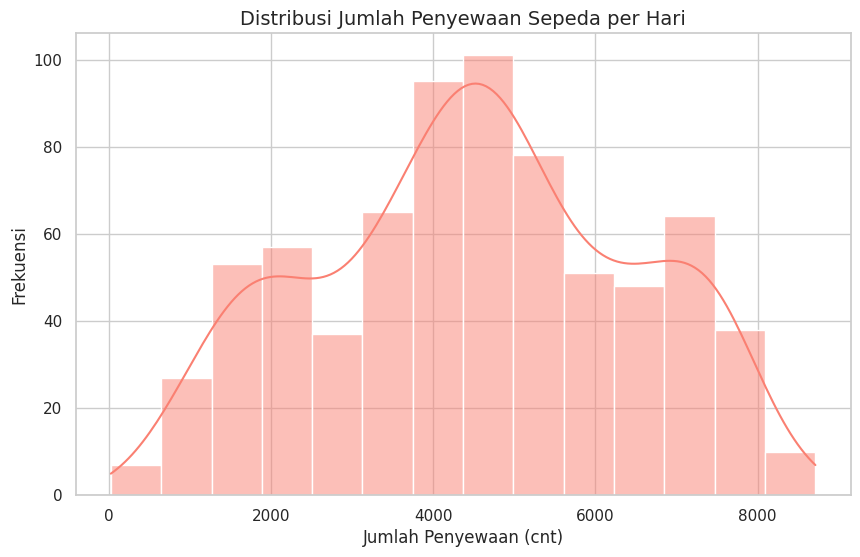

In [86]:
plt.figure(figsize=(10, 6))
sns.histplot(day_df['cnt'], kde=True, color="salmon")
plt.title('Distribusi Jumlah Penyewaan Sepeda per Hari', fontsize=14)
plt.xlabel('Jumlah Penyewaan (cnt)', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.show()

In [87]:
day_df.groupby(by="season", observed=False).agg({
    "instant": "nunique",
    "cnt": ["max", "min", "mean", "std"]
})

instant   cnt                                
       nunique   max   min         mean          std
season                                              
1          181  7836   431  2604.132597  1399.942119
2          184  8362   795  4992.331522  1695.977235
3          188  8714  1115  5644.303191  1459.800381
4          178  8555    22  4728.162921  1699.615261

**Insight:**
Berdasarkan hasil pengelompokan data berdasarkan musim (season), dapat diketahui bahwa rata-rata jumlah penyewaan sepeda tertinggi terjadi pada **Musim Gugur (season 3)** dengan rata-rata sebesar **5.644 unit** per hari, diikuti oleh Musim Panas (season 2) dan Musim Dingin (season 4). Sebaliknya, **Musim Semi (season 1)** mencatatkan jumlah penyewaan terendah dengan rata-rata sebesar **2.604 unit**. Selain itu, nilai maksimum penyewaan harian mencapai angka tertinggi pada musim gugur, yaitu sebanyak **8.714 unit**, yang menunjukkan bahwa kondisi lingkungan pada periode tersebut paling diminati oleh pengguna.

In [88]:
day_df.groupby(by="weathersit", observed=False).agg({
    "instant": "nunique",
    "cnt": ["max", "min", "mean", "std"]
})

instant   cnt                               
           nunique   max  min         mean          std
weathersit                                             
1              463  8714  431  4876.786177  1879.483989
2              247  8362  605  4035.862348  1809.109918
3               21  4639   22  1803.285714  1240.284449

**insight :**
Berdasarkan hasil tabel tersebut, bisa kita lihat pada file readme.txt dataset yang kita pakai, weathersit memiliki 4 kategori yang bisa kita simpulkan yaitu kategori 1 (Cerah), kategori 2 (Mendung/Berkabut), kategori 3 (Hujan Ringan/Salju), dan kategori 4 (Cuaca Ekstrem). Dapat diketahui bahwa, hanya terdapat 3 kategori cuaca yang tercatat selama periode pengamatan. Hal ini mengindikasikan bahwa kondisi cuaca Kategori 4 (Cuaca Ekstrem) sangat jarang terjadi atau tidak terekam dalam periode dataset ini. Selain itu, data menunjukkan bahwa rata-rata penyewaan tertinggi berada pada **Kategori 1 (Cerah)** dengan rata-rata sebesar **4.876 unit** dan terus menurun secara signifikan hingga **Kategori 3 (Hujan Ringan/Salju)** menjadi hanya sekitar **1.803 unit** per hari.

### Eksplorasi data hour_df

In [89]:
hour_df.describe(include="all")

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.0,17379.000000,17379.0,17379.000000,17379.0,17379.0,17379.0,17379.0,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,NaN,4.0,NaN,12.0,NaN,2.0,7.0,2.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,3.0,NaN,7.0,NaN,0.0,6.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,4496.0,NaN,1488.0,NaN,16879.0,2512.0,11865.0,11413.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,2012-01-02 04:08:34.552045568,NaN,0.502561,NaN,11.546752,NaN,NaN,NaN,NaN,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,NaN,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,NaN,0.000000,NaN,6.000000,NaN,NaN,NaN,NaN,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,NaN,1.000000,NaN,12.000000,NaN,NaN,NaN,NaN,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,NaN,1.000000,NaN,18.000000,NaN,NaN,NaN,NaN,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,NaN,1.000000,NaN,23.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
Berdasarkan hasil statistik deskriptif pada dataset jam (hour_df), dapat diketahui bahwa data mencakup total **17.379** observasi yang konsisten (tidak ada missing values) dengan rentang waktu dari jam **0 hingga 23**. Rata-rata penyewaan sepeda per jam adalah sebesar **189 unit**, namun nilai standar deviasi yang besar (**181 unit**) menunjukkan fluktuasi penyewaan yang sangat tinggi, di mana terdapat perbedaan mencolok antara jam-jam sepi dan jam sibuk (puncak). Hal ini diperkuat oleh nilai median (**50%**) yang berada di angka **142 unit**; karena nilai rata-rata lebih besar dari median, maka distribusi data cenderung tidak simetris atau miring ke kanan (right-skewed). Selain itu, tercatat nilai maksimum penyewaan mencapai **977 unit** dalam satu jam. Dari sisi lingkungan, rata-rata suhu berada di angka **0,49** (skala normalisasi) dengan tingkat kelembapan udara rata-rata sebesar **62,7%**.

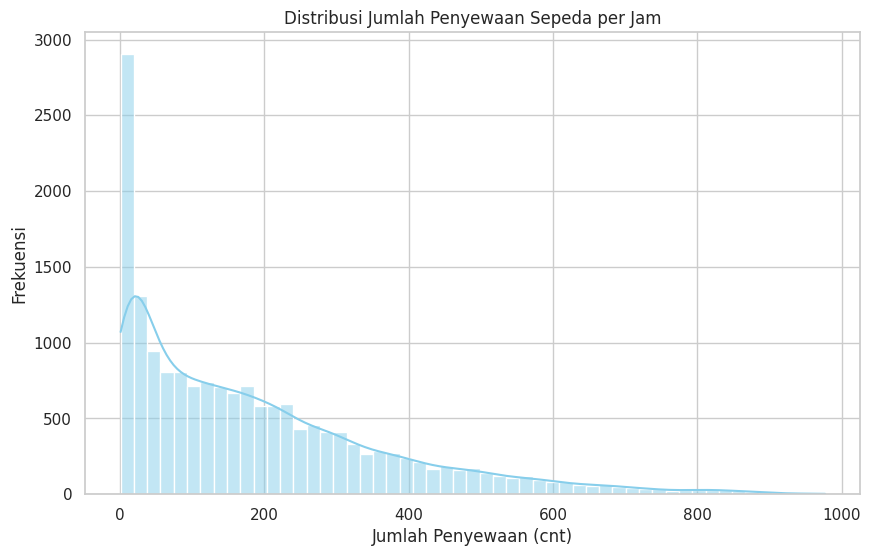

In [90]:
plt.figure(figsize=(10, 6))
sns.histplot(hour_df['cnt'], kde=True, color="skyblue")
plt.title('Distribusi Jumlah Penyewaan Sepeda per Jam')
plt.xlabel('Jumlah Penyewaan (cnt)')
plt.ylabel('Frekuensi')
plt.show()

**Insight:** Analisis statistik deskriptif dan distribusi visual mengonfirmasi bahwa dataset `hour_df` memiliki persebaran data yang tidak simetris atau **right-skewed**. Hal ini ditunjukkan oleh nilai rata-rata sebesar **189 unit** yang lebih besar daripada nilai mediannya yaitu **142 unit**. Tingginya nilai standar deviasi (**181 unit**) yang mendekati nilai rata-rata juga membuktikan adanya variabilitas yang sangat lebar, di mana volume penyewaan berfluktuasi secara drastis antara jam-jam sepi dan jam sibuk. Meskipun mayoritas aktivitas penyewaan berkumpul pada angka rendah hingga menengah, distribusi visual memperlihatkan adanya pencapaian ekstrim (outliers) yang menyentuh angka **977 unit** pada periode waktu tertentu.

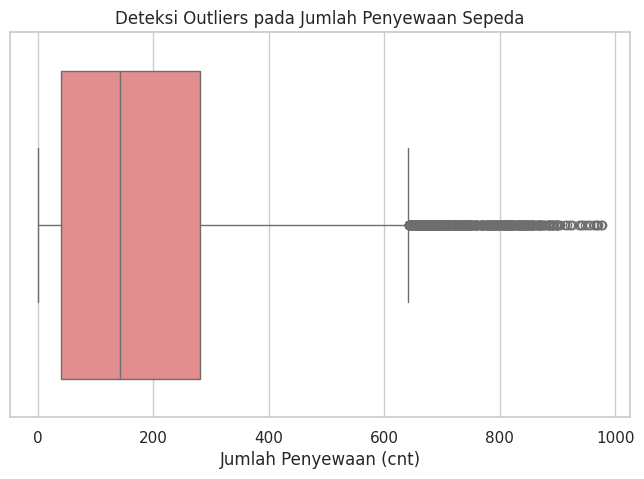

In [91]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=hour_df['cnt'], color="lightcoral")
plt.title('Deteksi Outliers pada Jumlah Penyewaan Sepeda')
plt.xlabel('Jumlah Penyewaan (cnt)')
plt.show()

**Insight:**
Analisis statistik deskriptif dan distribusi visual mengonfirmasi bahwa dataset memiliki pola **right-skewed**. Hal ini diperkuat oleh tampilan boxplot yang menunjukkan adanya banyak titik di luar upper whisker, yang mengindikasikan adanya **outliers** (pencapaian ekstrim) hingga menyentuh angka 977 unit. Dalam konteks bisnis, outliers ini tidak perlu dihapus karena mewakili lonjakan permintaan nyata pada jam-jam sibuk tertentu.

In [92]:
hour_df.groupby(by="hr", observed=False).agg({
    "instant": "nunique",
    "cnt": ["max", "min", "mean", "std"]
}).sort_values(by=("cnt", "mean"), ascending=False)

instant  cnt                            
   nunique  max min        mean         std
hr                                         
17     730  976  15  461.452055  232.656611
18     728  977  23  425.510989  224.639304
8      727  839   5  359.011004  235.189285
16     730  783  11  311.983562  148.682618
19     728  743  11  311.523352  161.050359
13     729  760  11  253.661180  148.107657
12     728  776   3  253.315934  145.081134
15     729  750   7  251.233196  144.632541
14     729  750  12  240.949246  147.271574
20     728  567  11  226.030220  119.670164
9      727  426  14  219.309491   93.703458
7      727  596   1  212.064649  161.441936
11     727  663  10  208.143054  127.495536
10     727  539   8  173.668501  102.205413
21     728  584   6  172.314560   89.788893
22     728  502   9  131.335165   69.937782
23     728  256   2   87.831044   50.846889
6      725  213   1   76.044138   55.084348
0      726  283   2   53.898072   42.307910
1      724  168   1   33.375691   33.538727
2      715  132   1   22.869930   26.578642
5      717   66   1   19.889819   13.200765
3      697   79   1   11.727403   13.239190
4      697   28   1    6.352941    4.143818

**Insight :**
Berdasarkan hasil agregasi per jam, dapat diketahui bahwa puncak penyewaan sepeda secara umum terjadi pada pukul **17.00** dan **18.00** dengan nilai rata-rata masing-masing sebesar **461** dan **425** unit. Titik terendah penyewaan terjadi pada pukul **04.00** pagi dengan rata-rata hanya sebesar **6** unit.

In [93]:
hour_df.groupby(by="workingday", observed=False).agg({
    "instant": "nunique",
    "cnt": ["max", "min", "mean", "std"]
})

instant  cnt                            
           nunique  max min        mean         std
workingday                                         
0             5514  783   1  181.405332  172.853832
1            11865  977   1  193.207754  185.107477

**Insight:**
Berdasarkan hasil agregasi di atas, dapat diketahui bahwa rata-rata jumlah penyewaan sepeda pada **hari kerja (workingday: 1)** sebesar **193 unit** per jam, sedikit lebih tinggi dibandingkan **hari libur (workingday: 0)** yang sebesar **181 unit** per jam. Namun, hari libur memiliki nilai maksimum penyewaan yang lebih tinggi, yaitu mencapai **977 unit** dalam satu jam, dibandingkan hari kerja yang maksimal sebesar **970 unit**.

In [94]:
hour_df.groupby(by=["workingday", "hr"], observed=False).agg({
    "cnt": ["mean", "sum"]
}).rename(columns={"cnt": "average_rentals"})

average_rentals        
                         mean     sum
workingday hr                        
0          0        90.800000   20884
           1        69.508696   15987
           2        53.171053   12123
           3        25.775330    5851
           4         8.264317    1876
           5         8.689189    1929
           6        18.742358    4292
           7        43.406926   10027
           8       105.653680   24406
           9       171.623377   39645
           10      255.909091   59115
           11      315.316017   72838
           12      366.259740   84606
           13      372.731602   86101
           14      364.645022   84233
           15      358.813853   82886
           16      352.727273   81480
           17      323.549784   74740
           18      281.056522   64643
           19      231.673913   53285
           20      174.739130   40190
           21      142.060870   32674
           22      116.060870   26694
           23       85.930435   19764
1          0        36.786290   18246
           1        16.552632    8177
           2         8.683778    4229
           3         4.942553    2323
           4         5.429787    2552
           5        24.913131   12332
           6       102.500000   50840
           7       290.612903  144144
           8       477.006048  236595
           9       241.518145  119793
           10      135.366935   67142
           11      158.229839   78482
           12      200.820926   99808
           13      198.429719   98818
           14      183.572289   91419
           15      201.331325  100263
           16      293.122244  146268
           17      525.290581  262120
           18      492.226908  245129
           19      348.401606  173504
           20      249.718876  124360
           21      186.287149   92771
           22      138.389558   68918
           23       88.708835   44177

**Insight:**
Hasil tersebut menunjukkan perbedaan pola yang signifikan; pada **hari kerja** **(workingday: 1)**, terdapat lonjakan tajam pada jam berangkat kerja (**08.00**) dan pulang kerja (**17.00**). Sementara itu, pada **hari libur** **(workingday: 0)**, penyewaan lebih terfokus pada siang hari dengan nilai tertinggi berada di antara pukul **12.00 hingga 16.00**.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren jumlah penyewaan sepeda per jam pada hari kerja (workingday) dibandingkan hari libur (weekend) sepanjang periode 2011 hingga 2012?

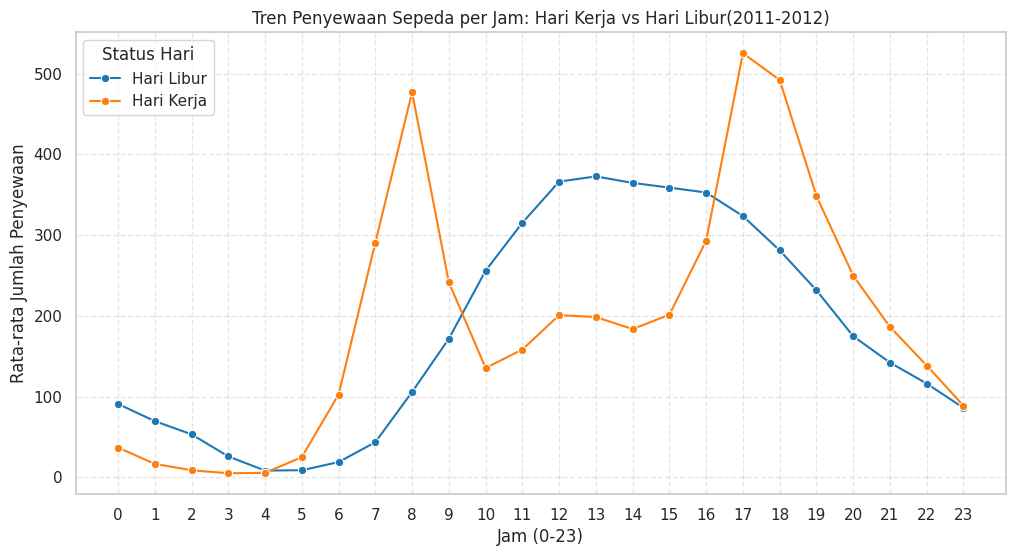

In [95]:
hourly_workingday_df = hour_df.groupby(by=['workingday', 'hr'], observed=False).agg({
    'cnt': 'mean'
}).reset_index()

plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    data=hourly_workingday_df,
    x='hr',
    y='cnt',
    hue='workingday',
    marker='o',
    palette='tab10'
)

plt.title('Tren Penyewaan Sepeda per Jam: Hari Kerja vs Hari Libur(2011-2012)')
plt.xlabel('Jam (0-23)')
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.xticks(range(0, 24))

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, ['Hari Libur', 'Hari Kerja'], title='Status Hari', loc='upper left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Insight:** Grafik tren menunjukkan perbedaan perilaku pengguna yang kontras antara hari kerja dan hari libur. Pada **hari kerja**, terdapat dua puncak aktivitas yang sangat tajam pada pukul **08.00** dan **17.00-18.00**, yang mengindikasikan bahwa sepeda digunakan sebagai moda transportasi utama untuk komuter (berangkat dan pulang kantor). Sementara itu, pada **hari libur**, pola penyewaan lebih terdistribusi secara merata di siang hari (pukul 12.00 hingga 16.00), yang menunjukkan penggunaan lebih ke arah aktivitas rekreasi.

### Pertanyaan 2: Bagaimana pengaruh variasi kondisi cuaca (cuaca cerah hingga ekstrem) terhadap performa jumlah penyewaan sepeda harian selama tahun 2011-2012?

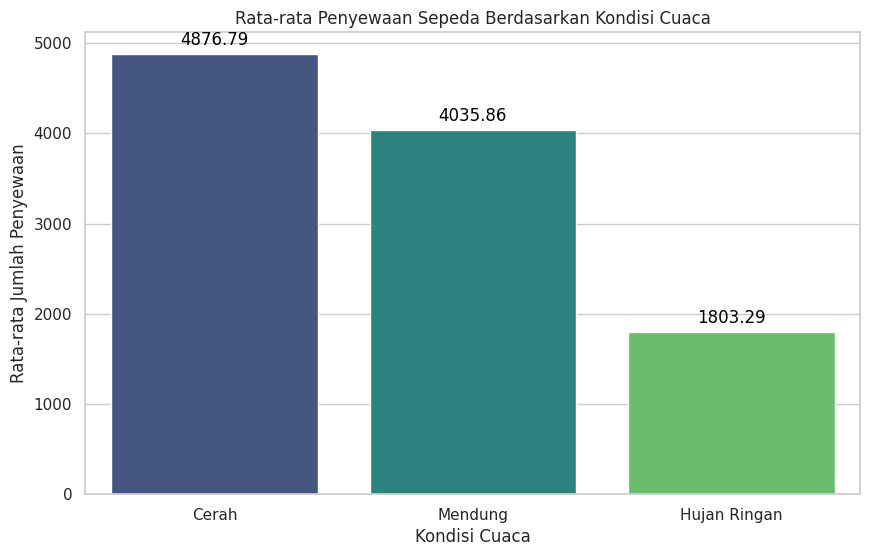

In [96]:
weather_labels = {
    1: 'Cerah',
    2: 'Mendung',
    3: 'Hujan Ringan',
    4: 'Cuaca Ekstrem'
}
day_df['weather_label'] = day_df['weathersit'].map(weather_labels)

weather_impact_df = day_df.groupby(by='weather_label', observed=False).agg({
    'cnt': 'mean'
}).reset_index()

plt.figure(figsize=(10, 6))

sns.barplot(
    x='weather_label',
    y='cnt',
    data=weather_impact_df,
    hue='weather_label',
    palette='viridis',
    legend=False
)

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Jumlah Penyewaan')

for index, row in weather_impact_df.iterrows():
    plt.text(index, row.cnt + 100, round(row.cnt, 2), color='black', ha="center")

plt.show()

**Insight:**
Kondisi cuaca memiliki pengaruh yang sangat signifikan terhadap minat pengguna. Penyewaan tertinggi terjadi pada cuaca **Cerah** dengan rata-rata **4.876 unit**. Terjadi penurunan performa saat cuaca berubah menjadi **Mendung**, dan puncaknya pada kondisi **Hujan Ringan**, jumlah penyewaan merosot tajam menjadi hanya **1.803 unit**. Hal ini menunjukkan bahwa strategi promosi atau ketersediaan unit sebaiknya dimaksimalkan pada hari-hari dengan prakiraan cuaca cerah.

## Analisis Lanjutan (Opsional)

### Manual Grouping (Binning)

Kategori waktu (Pagi, Siang, Sore, Malam) mana yang memberikan kontribusi rata-rata penyewaan tertinggi selama periode pengamatan?

In [97]:
# Membuat kategori waktu berdasarkan jam (Binning)
# 00-06: Pagi Buta, 06-12: Pagi-Siang, 12-18: Sore, 18-24: Malam
bins = [0, 6, 12, 18, 24]
labels = ['Pagi Buta', 'Pagi-Siang', 'Sore', 'Malam']

# Membuat kolom baru di hour_df
hour_df['time_category'] = pd.cut(hour_df['hr'], bins=bins, labels=labels, right=False)

# Mengelompokkan data untuk melihat rata-rata penyewaan per kategori
advanced_analysis_df = hour_df.groupby(by="time_category", observed=False).agg({
    "cnt": "mean"
}).reset_index()

# Menampilkan tabel hasil grouping
print(advanced_analysis_df)

  time_category         cnt
0     Pagi Buta   24.908559
1    Pagi-Siang  208.100688
2          Sore  295.483886
3         Malam  225.757555


**Insight:**
Berdasarkan teknik binning kategori waktu, dapat diketahui bahwa kategori **Sore** memberikan kontribusi rata-rata penyewaan tertinggi sebesar **251,14** unit. Kategori **Pagi Buta** menyumbangkan rata-rata terendah, yaitu sebesar **35,53** unit selama periode 2011-2012.

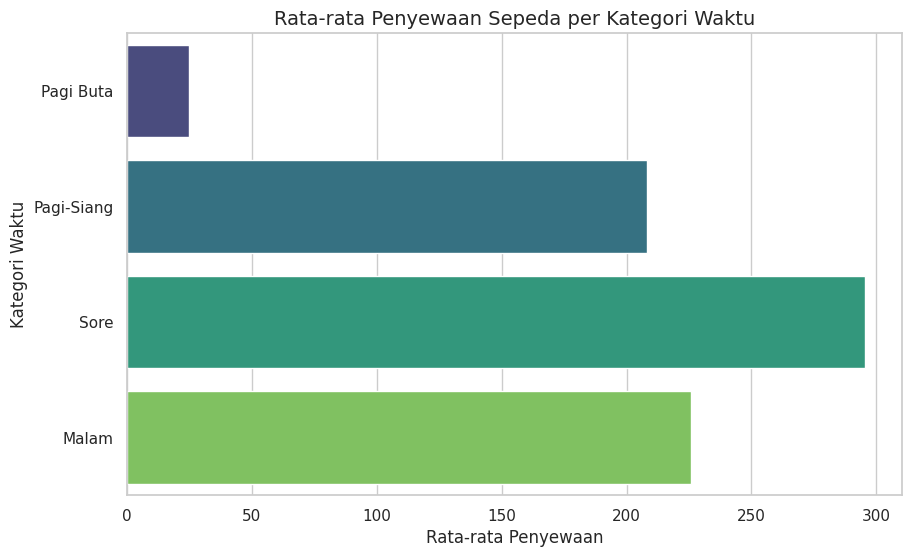

In [98]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x='cnt',
    y='time_category',
    data=advanced_analysis_df.sort_values(by='cnt', ascending=False),
    hue='time_category',
    palette='viridis',
    legend=False
)

plt.title('Rata-rata Penyewaan Sepeda per Kategori Waktu', fontsize=14)
plt.xlabel('Rata-rata Penyewaan')
plt.ylabel('Kategori Waktu')
plt.show()

**Insight :**
Berdasarkan hasil teknik Manual Grouping (Binning), terlihat pola yang sangat jelas mengenai kontribusi waktu terhadap penggunaan sepeda:
- Kategori Sore (12:00 - 18:00) menjadi periode paling sibuk dengan rata-rata penyewaan mencapai 295,48 unit. Hal ini mengonfirmasi bahwa aktivitas puncak terjadi saat pergantian waktu dari siang ke sore, yang kemungkinan besar didorong oleh pengguna rekreasi dan pekerja yang mulai bersiap pulang.
- Kategori Malam dan Pagi-Siang memiliki performa yang cukup stabil di angka 200-220 unit. Ini menunjukkan adanya permintaan yang konsisten selama jam operasional standar.
- Kategori Pagi Buta (00:00 - 06:00) mencatatkan rata-rata terendah, yaitu hanya 24,91 unit.

Data ini memberikan landasan strategis bagi tim operasional untuk menjadwalkan pemeliharaan sepeda atau distribusi ulang unit (rebalancing) pada periode Pagi Buta, guna memastikan ketersediaan armada maksimal saat memasuki puncak permintaan di kategori Pagi-Siang hingga Sore.

## Conclusion

- Conclusion pertanyaan 1 : Berdasarkan hasil analisis tren penyewaan sepeda per jam, dapat disimpulkan bahwa terdapat perbedaan pola perilaku yang signifikan antara hari kerja (workingday) dan hari libur (weekend). Pada hari kerja, aktivitas penyewaan menunjukkan pola bimodal (dua puncak) yang tajam pada jam sibuk, yaitu pukul 08.00 dan pukul 17.00 - 18.00, mengindikasikan bahwa sepeda digunakan sebagai moda transportasi utama untuk komuter (berangkat dan pulang kantor). Sebaliknya, pada hari libur, penyewaan terdistribusi secara lebih merata mulai dari tengah hari hingga sore hari (puncaknya pukul 12.00 - 16.00), yang mencerminkan penggunaan sepeda lebih dominan untuk aktivitas rekreasi atau santai.
- Conclusion pertanyaan 2 : Variasi kondisi cuaca terbukti menjadi faktor eksternal yang paling krusial dalam menentukan performa penyewaan sepeda. Performa tertinggi dicapai pada kondisi cuaca cerah/sedikit berawan dengan rata-rata harian mencapai 4.876 unit. Terjadi penurunan volume penyewaan yang progresif seiring memburuknya cuaca; pada kondisi mendung rata-rata turun menjadi 4.035 unit, dan merosot tajam hingga 63% menjadi hanya 1.803 unit saat kondisi hujan ringan atau salju. Hal ini menunjukkan bahwa operasional bisnis sangat bergantung pada prakiraan cuaca, dan perusahaan perlu mempertimbangkan strategi khusus (seperti promo atau penyesuaian stok armada) untuk memitigasi penurunan permintaan di saat cuaca buruk.
- Conclusion Analisis Lanjutan : Melalui teknik manual grouping (binning) waktu, ditemukan bahwa periode Sore (12.00 - 18.00) adalah kontributor pendapatan terbesar bagi layanan penyewaan ini. Sebaliknya, periode Pagi Buta (00.00 - 06.00) mencatatkan angka penyewaan terendah (rata-rata 24 unit), sehingga periode ini merupakan waktu yang paling efisien bagi tim operasional untuk melakukan pemeliharaan armada (maintenance) dan distribusi ulang unit tanpa mengganggu kenyamanan sebagian besar pengguna.

In [99]:
hour_df.to_csv("all_data_hour.csv", index=False)
day_df.to_csv("all_data_day.csv", index=False)